# Analyse des données League of Legends

**Problématique** : Analyser et trouver quel est le meilleur champion et quels sont les rôles et les positions les plus représentés

#### Initialisation des librairies

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

path = "data/"

#### Initialisation des Datasets

##### Champion Dataset

In [ ]:
champs = pd.read_csv(path + "champs.csv")

##### Participants Dataset

In [ ]:
participants = pd.read_csv(path + "participants.csv")

##### Matches Dataset

In [ ]:
matches = pd.read_csv(path + "matches.csv")

##### Stat1 Dataset

In [ ]:
stats1 = pd.read_csv(path + "stats1.csv")

##### Stat2 Dataset

In [ ]:
stats2 = pd.read_csv(path + "stats2.csv", na_values=[r"\N"], dtype={"wardsbought": "Int64"})

##### Team Bans Dataframe

In [ ]:
teambans = pd.read_csv(path + "teambans.csv")

##### Team Stats Dataframe

In [ ]:
teamstats = pd.read_csv(path + "teamstats.csv")

#### Tests et analyse

In [ ]:
# python
# quick diagnostics
print(participants.shape)
print(participants.columns.tolist())
print(participants['position'].dtype, participants['role'].dtype)
print(participants['position'].isna().sum(), participants['role'].isna().sum())
print(participants[['position', 'role']].head())

# vectorized fix (fast)
mask_bot = participants['position'] == "BOT"
participants.loc[mask_bot & (participants['role'] == 'DUO_SUPPORT'), 'position'] = "SUPP"
participants.loc[mask_bot & (participants['role'] != 'DUO_SUPPORT'), 'position'] = "ADC"

# verify
participants.loc[:, ["position", "role"]].head()

print(participants['championid'].dtype, champs['id'].dtype)


In [37]:
participants["teamid"] = participants.player.apply(lambda x: 100 if x <= 5 else 200)

keep_cols_stats = ["id", "win", "kills"]
keep_cols_participants = ['id', 'champion_name', 'player', 'win', 'kills', 'deaths', 'assists', 'totdmgdealt', 'ss1',
                          'ss2',
                          'position']

stats = pd.concat([stats1, stats2])

train_data = pd.merge(participants, teamstats.drop(["firstblood"], axis=1), on=["matchid", "teamid"])
train_data = pd.merge(participants, stats, how='left', on=['id'], suffixes=('', '_y'))

champs_info = champs[['id', 'name']].rename(columns={'name': 'champion_name'})

train_data = pd.merge(train_data, champs_info, left_on='championid', right_on='id', how='left', suffixes=('', '_champ'))

train_data = train_data[keep_cols_participants]
only_winners = train_data[train_data["win"] == 1]

only_winners

,id,champion_name,player,win,kills,deaths,assists,totdmgdealt,ss1,ss2,position
5,14,Skarner,6,1.0,3.0,3.0,9.0,148791.0,11,4,JUNGLE
6,15,Galio,7,1.0,4.0,5.0,11.0,130692.0,4,12,TOP
7,16,Ahri,8,1.0,13.0,4.0,8.0,145731.0,14,4,MID
8,17,Jinx,9,1.0,15.0,3.0,9.0,182680.0,7,4,ADC
9,18,VelKoz,10,1.0,4.0,5.0,19.0,85785.0,14,4,SUPP
...,...,...,...,...,...,...,...,...,...,...,...
1834510,1865595,Twisted Fate,1,1.0,3.0,14.0,7.0,166561.0,4,12,MID
1834511,1865596,Tristana,2,1.0,10.0,6.0,11.0,220556.0,7,4,ADC
1834512,1865597,Xin Zhao,3,1.0,22.0,9.0,15.0,285357.0,4,11,JUNGLE
1834513,1865598,Malphite,4,1.0,7.0,4.0,22.0,125706.0,12,4,TOP


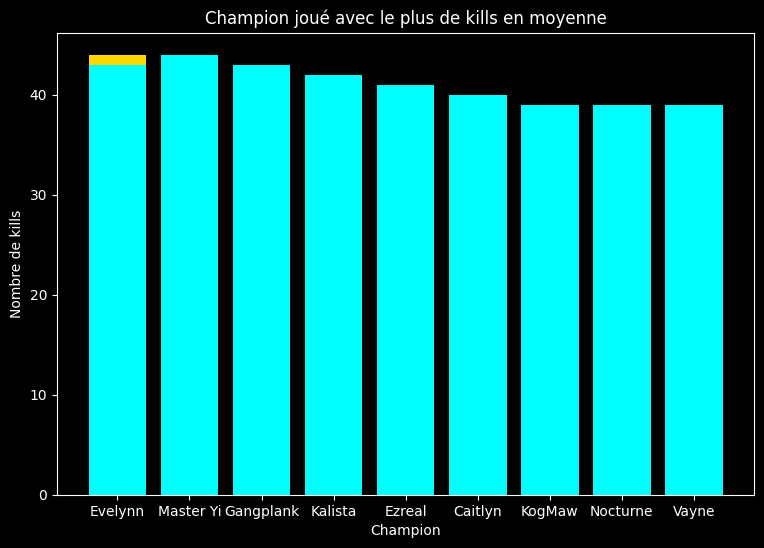

In [63]:
plt.figure(figsize=(9, 6))

selectedKills = only_winners.groupby("champion_name").agg(
    {"kills": "mean", "deaths": "mean", "assists": "mean"}).reset_index()
selectedKills = only_winners.sort_values(by="kills", ascending=False).head(10)

plt.bar(selectedKills["champion_name"], selectedKills["kills"],
        color=['gold' if i == 0 else 'cyan' for i in range(len(selectedKills))])

plt.title("Champion joué avec le plus de kills en moyenne")
plt.xlabel("Champion")
plt.ylabel("Nombre de kills")
plt.show()

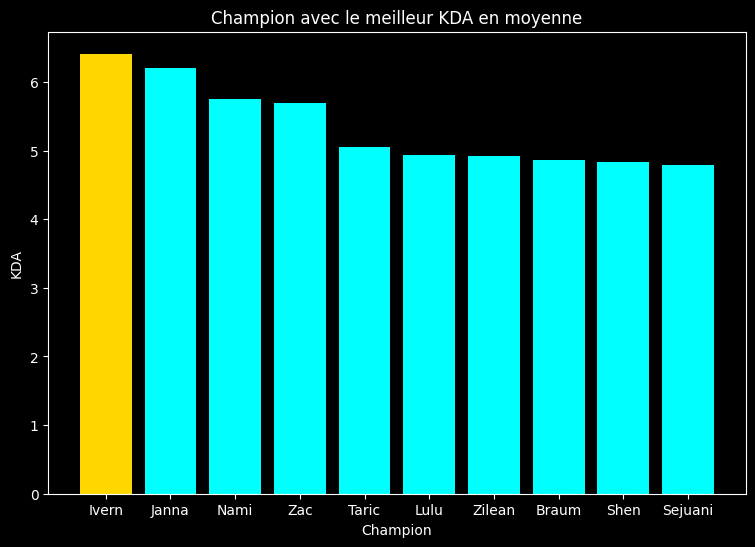

In [64]:
plt.figure(figsize=(9, 6))

selectedKDA = only_winners.groupby("champion_name").agg(
    {"kills": "mean", "deaths": "mean", "assists": "mean"}).reset_index()
selectedKDA["KDA"] = (selectedKDA["kills"] + selectedKDA["assists"]) / selectedKDA["deaths"].replace(0, 1)

selectedKDA = selectedKDA.sort_values(by="KDA", ascending=False).head(10)
plt.bar(selectedKDA["champion_name"], selectedKDA["KDA"],
        color=['gold' if i == 0 else 'cyan' for i in range(len(selectedKDA))])
plt.title("Champion avec le meilleur KDA en moyenne")
plt.xlabel("Champion")
plt.ylabel("KDA")
plt.show()

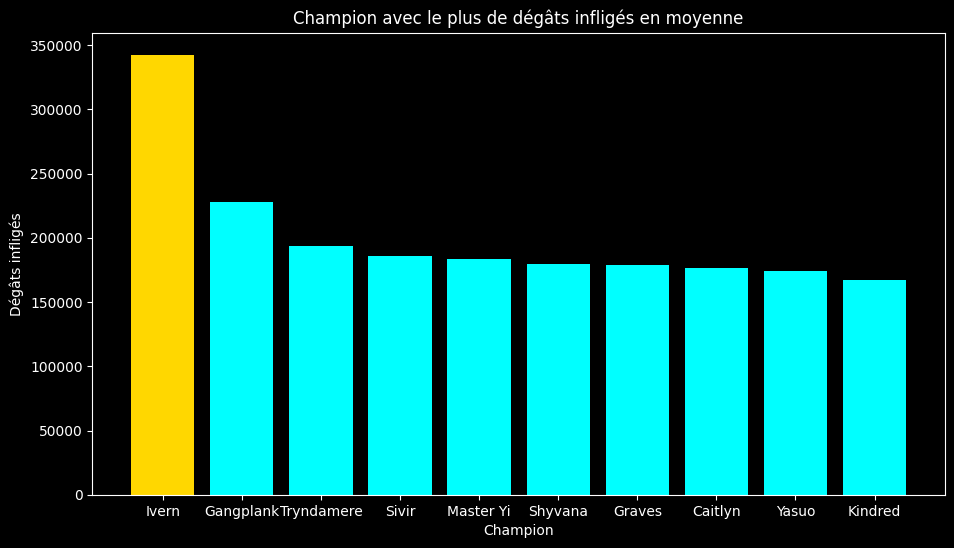

In [65]:
plt.figure(figsize=(11, 6))

selectedTotDmg = only_winners.groupby("champion_name").agg(
    {"totdmgdealt": "mean"}).reset_index()
selectedTotDmg = selectedTotDmg.sort_values(by="totdmgdealt", ascending=False).head(10)
plt.bar(selectedTotDmg["champion_name"], selectedTotDmg["totdmgdealt"],
        color=['gold' if i == 0 else 'cyan' for i in range(len(selectedTotDmg))])
plt.title("Champion avec le plus de dégâts infligés en moyenne")
plt.xlabel("Champion")
plt.ylabel("Dégâts infligés")
plt.show()

In [69]:
plt.figure(figsize=(9, 6))

best_overall = [
    selectedKills["champion_name"],
    selectedKDA["champion_name"],
    selectedTotDmg["champion_name"]
]
print(best_overall)

[1260209      Evelynn
1247955    Master Yi
1671216    Gangplank
429983       Evelynn
1653623      Kalista
945803        Ezreal
1189211      Caitlyn
944852        KogMaw
658947      Nocturne
1809333        Vayne
Name: champion_name, dtype: str, 40       Ivern
41       Janna
72        Nami
131        Zac
106      Taric
63        Lulu
134     Zilean
13       Braum
93        Shen
91     Sejuani
Name: champion_name, dtype: str, 40          Ivern
31      Gangplank
111    Tryndamere
97          Sivir
68      Master Yi
94        Shyvana
35         Graves
14        Caitlyn
129         Yasuo
55        Kindred
Name: champion_name, dtype: str]


<Figure size 900x600 with 0 Axes>